# Soil Site Point Density Raster — Ecuador

In [1]:
# Shared imports and globals for this notebook
from pathlib import Path

import contextily as ctx
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pyproj import Transformer
from rasterio.features import geometry_mask
from rasterio.mask import mask as rio_mask
from rasterio.transform import from_bounds
from scipy.stats import gaussian_kde
from shapely.geometry import Polygon as ShapelyPolygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
from matplotlib_scalebar.scalebar import ScaleBar

# Keep one shared CRS definition used across cells
PROJ_CRS = "EPSG:32717"

In [2]:

# --- Paths ---
points_path = r"data\sites_sg\sg_sites_points.shp"
boundary_path = r"C:\Soilgrids\data\adm_ecu\ecu_mainland_boundary.shp"
output_raster = r"data\sg_site_density.tif"


In [3]:
# Load and reproject both layers
boundary = gpd.read_file(boundary_path).to_crs(PROJ_CRS)
points   = gpd.read_file(points_path).to_crs(PROJ_CRS)

print(f"Boundary CRS : {boundary.crs}")
print(f"Points CRS   : {points.crs}")
print(f"Total sites  : {len(points)}")


DataSourceError: C:\Soilgrids\data\adm_ecu\ecu_mainland_boundary.shp: No such file or directory

In [ ]:
# --- Raster grid settings ---
RESOLUTION = 5000   # cell size in metres (5 km); lower = finer, slower
BANDWIDTH  = 30000  # KDE bandwidth in metres (30 km); controls smoothing

# Build grid from the Ecuador boundary extent
minx, miny, maxx, maxy = boundary.total_bounds

cols = int((maxx - minx) / RESOLUTION)
rows = int((maxy - miny) / RESOLUTION)
print(f"Grid size: {cols} cols × {rows} rows  ({cols*rows:,} cells)")

# Grid cell-centre coordinates
xs = np.linspace(minx + RESOLUTION / 2, maxx - RESOLUTION / 2, cols)
ys = np.linspace(maxy - RESOLUTION / 2, miny + RESOLUTION / 2, rows)  # top→bottom
xx, yy = np.meshgrid(xs, ys)
grid_coords = np.vstack([xx.ravel(), yy.ravel()])


Grid size: 129 cols × 143 rows  (18,447 cells)


In [ ]:
# --- Kernel Density Estimation ---
point_coords = np.vstack([points.geometry.x, points.geometry.y])

# Scale by bandwidth so scipy's bw_method='scott' acts in metres
bw = BANDWIDTH / point_coords.std(axis=1).mean()
kde = gaussian_kde(point_coords, bw_method=bw)

print("Running KDE on grid (may take a moment)…")
density = kde(grid_coords).reshape(rows, cols)

# Optionally scale to points-per-km²
cell_area_km2 = (RESOLUTION / 1000) ** 2
density_per_km2 = density * len(points) / cell_area_km2

print(f"Max density: {density_per_km2.max():.4f} sites/km²")


Running KDE on grid (may take a moment)…
Max density: 0.0000 sites/km²


In [ ]:
# --- Mask to Ecuador boundary ---
transform = from_bounds(minx, miny, maxx, maxy, cols, rows)

mask = geometry_mask(
    boundary.geometry,
    transform=transform,
    invert=True,   # True inside Ecuador
    out_shape=(rows, cols),
)

density_masked = np.where(mask, density_per_km2, np.nan)


In [ ]:
# --- Save as GeoTIFF ---
Path(output_raster).parent.mkdir(parents=True, exist_ok=True)

with rasterio.open(
    output_raster,
    "w",
    driver="GTiff",
    height=rows,
    width=cols,
    count=1,
    dtype="float32",
    crs=PROJ_CRS,
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(density_masked.astype("float32"), 1)

print(f"Saved: {output_raster}")


Saved: data\sg_site_density.tif


C:\Users\UDA\AppData\Local\Temp\ipykernel_8636\2047785701.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{lon:.1f}°" for lon in lon_labels])
C:\Users\UDA\AppData\Local\Temp\ipykernel_8636\2047785701.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{lat:.1f}°" for lat in lat_labels])


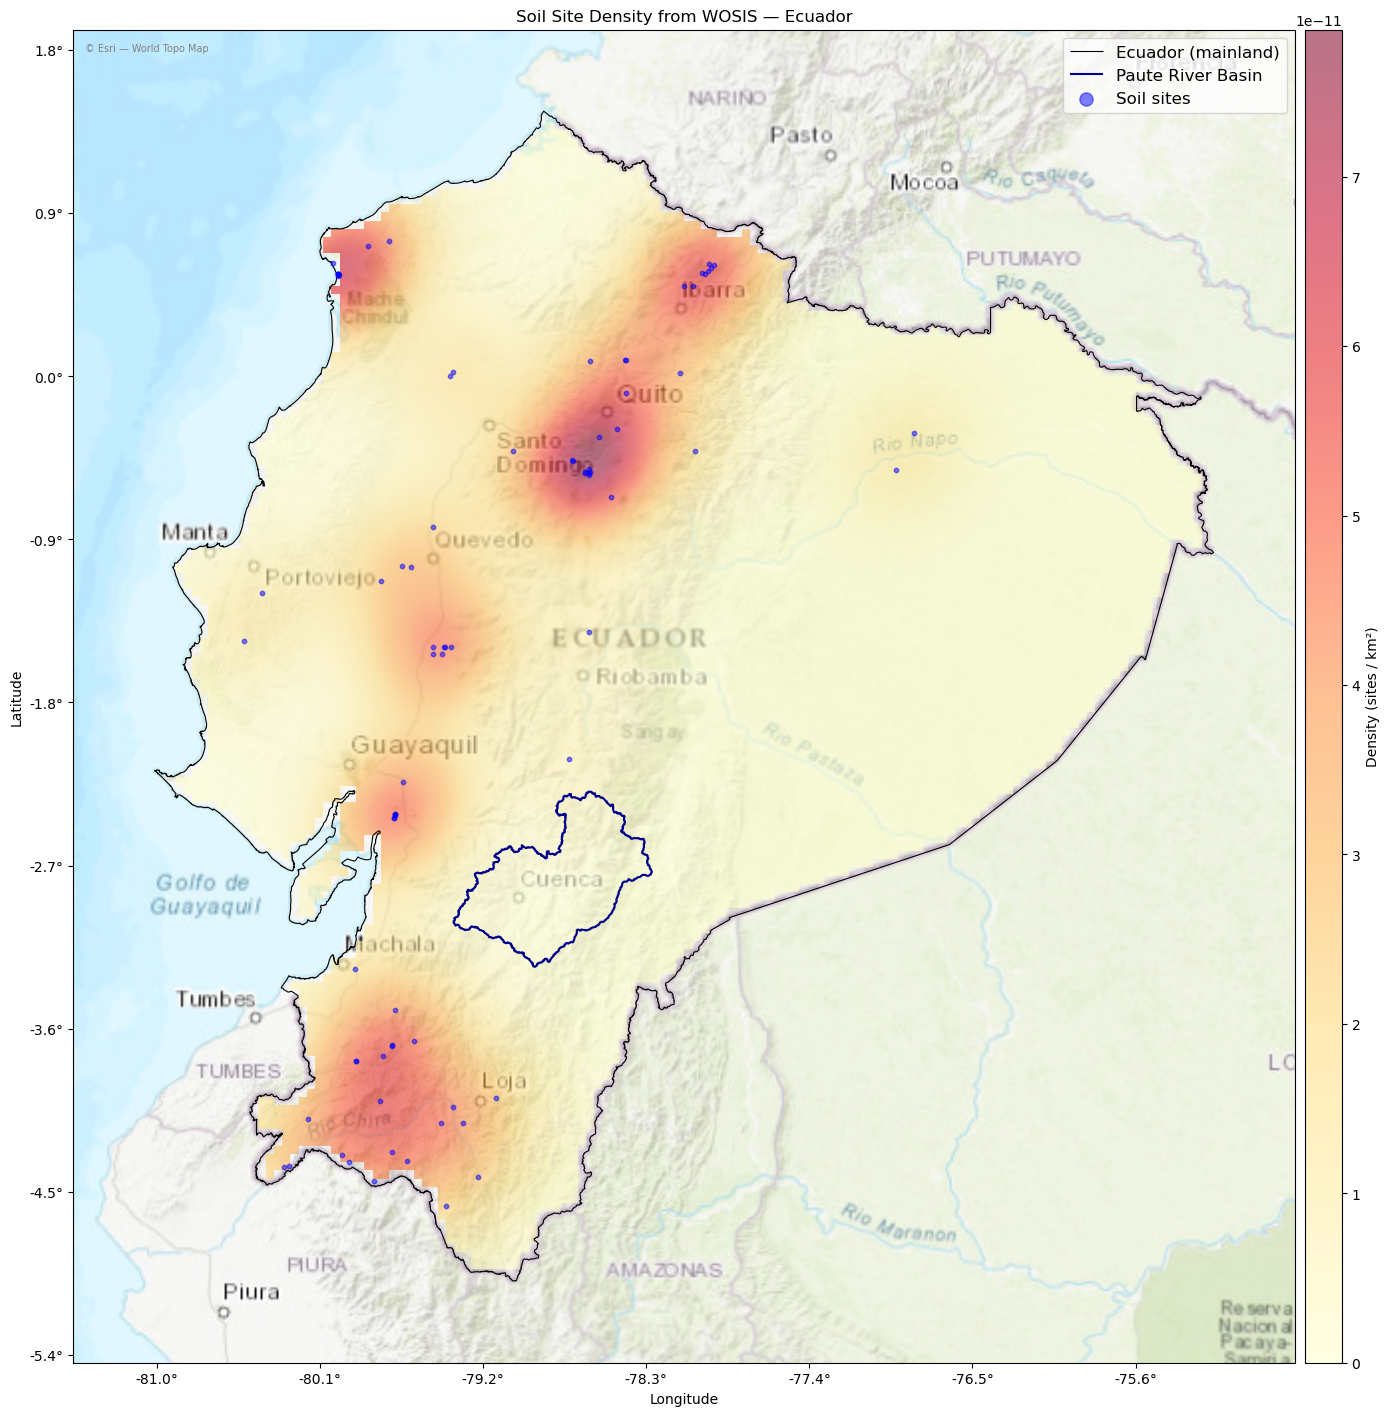

In [ ]:

paute_basin_proj = gpd.read_file(r"data\cuencas\PauteBasin.gpkg").to_crs(PROJ_CRS)

fig, ax = plt.subplots(figsize=(14, 18))

# Add padding beyond the boundary extent (in metres)
PAD = 50_000  # 50 km buffer on each side
ax.set_xlim(minx - PAD, maxx + PAD)
ax.set_ylim(miny - PAD, maxy + PAD)
ctx.add_basemap(ax, crs=PROJ_CRS, source=ctx.providers.Esri.WorldTopoMap, zoom="auto",
                attribution=False)

# Add attribution manually at the top of the plot
ax.text(0.01, 0.99, "© Esri — World Topo Map",
        transform=ax.transAxes, fontsize=7, color="gray",
        ha="left", va="top", zorder=10)

im = ax.imshow(
    density_masked,
    extent=[minx, maxx, miny, maxy],
    origin="upper",
    cmap="YlOrRd",
    interpolation="bilinear",
    alpha=0.55,
    zorder=2,
)

boundary.boundary.plot(ax=ax, color="black", linewidth=0.8, zorder=3, label="Ecuador (mainland)")
paute_basin_proj.boundary.plot(ax=ax, color="darkblue", linewidth=1.5, zorder=3, label="Paute River Basin")
points.plot(ax=ax, color="blue", markersize=10, alpha=0.5, label="Soil sites", zorder=4)

# Colorbar matched to the map height
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
plt.colorbar(im, cax=cax, label="Density (sites / km²)")

# Convert tick labels from UTM to lat/lon
proj_to_geo = Transformer.from_crs(PROJ_CRS, "EPSG:4326", always_xy=True)

xticks = ax.get_xticks()
yticks = ax.get_yticks()

lon_labels, _ = proj_to_geo.transform(xticks, np.full_like(xticks, (miny + maxy) / 2))
_, lat_labels = proj_to_geo.transform(np.full_like(yticks, (minx + maxx) / 2), yticks)

ax.set_xticklabels([f"{lon:.1f}°" for lon in lon_labels])
ax.set_yticklabels([f"{lat:.1f}°" for lat in lat_labels])

ax.set_title("Soil Site Density from WOSIS — Ecuador")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(fontsize=12, markerscale=3)
plt.tight_layout()
plt.show()


C:\Users\UDA\AppData\Local\Temp\ipykernel_22008\1471142674.py:29: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  points_azuay.plot(ax=ax, color="blue", markersize=10, alpha=0.6, label=f"Soil sites (n={len(points_azuay)})", zorder=4)
C:\Users\UDA\AppData\Local\Temp\ipykernel_22008\1471142674.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{lon:.1f}°" for lon in lon_labels])
C:\Users\UDA\AppData\Local\Temp\ipykernel_22008\1471142674.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{lat:.1f}°" for lat in lat_labels])
C:\Users\UDA\AppData\Local\Temp\ipykernel_22008\1471142674.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() i

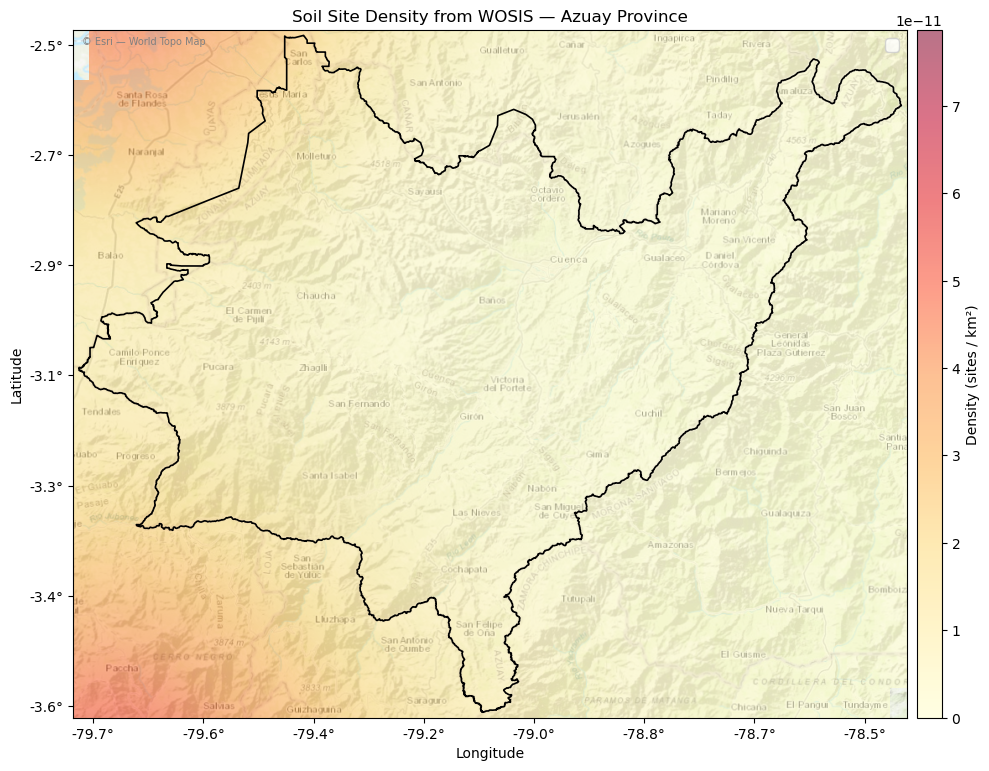

In [ ]:
paute_basin_proj = gpd.read_file(r"data\cuencas\PauteBasin.gpkg").to_crs(PROJ_CRS)
pb_minx, pb_miny, pb_maxx, pb_maxy = paute_basin_proj.total_bounds

fig, ax = plt.subplots(figsize=(10, 10))

PAD_PB = 5_000  # 5 km buffer
ax.set_xlim(pb_minx - PAD_PB, pb_maxx + PAD_PB)
ax.set_ylim(pb_miny - PAD_PB, pb_maxy + PAD_PB)
ctx.add_basemap(ax, crs=PROJ_CRS, source=ctx.providers.Esri.WorldTopoMap, zoom="auto",
                attribution=False)

ax.text(0.01, 0.99, "© Esri — World Topo Map",
        transform=ax.transAxes, fontsize=7, color="gray",
        ha="left", va="top", zorder=10)

im = ax.imshow(
    density_masked,
    extent=[minx, maxx, miny, maxy],
    origin="upper",
    cmap="YlOrRd",
    interpolation="bilinear",
    alpha=0.55,
    zorder=2,
)

paute_basin_proj.boundary.plot(ax=ax, color="black", linewidth=1.2, zorder=3)

points_paute = points[points.within(paute_basin_proj.union_all())]
points_paute.plot(ax=ax, color="blue", markersize=10, alpha=0.6, label=f"Soil sites (n={len(points_paute)})", zorder=4)

# Colorbar matched to the map height
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
plt.colorbar(im, cax=cax, label="Density (sites / km²)")

ax.set_xlim(pb_minx - PAD_PB, pb_maxx + PAD_PB)
ax.set_ylim(pb_miny - PAD_PB, pb_maxy + PAD_PB)

# Convert tick labels from UTM to lat/lon
proj_to_geo = Transformer.from_crs(PROJ_CRS, "EPSG:4326", always_xy=True)

xticks = ax.get_xticks()
yticks = ax.get_yticks()

lon_labels, _ = proj_to_geo.transform(xticks, np.full_like(xticks, (pb_miny + pb_maxy) / 2))
_, lat_labels = proj_to_geo.transform(np.full_like(yticks, (pb_minx + pb_maxx) / 2), yticks)

ax.set_xticklabels([f"{lon:.1f}°" for lon in lon_labels])
ax.set_yticklabels([f"{lat:.1f}°" for lat in lat_labels])

ax.set_title("Soil Site Density from WOSIS — Paute River Basin")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(fontsize=12, markerscale=3)
plt.tight_layout()
plt.show()


Subbasins: 18 features, CRS: EPSG:24877
Bounding box: [ 682016.50912917 9638339.33314606  803693.12498801 9745737.08019008]
Geometry type after merge: Polygon
Saved dissolved basin to data\cuencas\PauteBasin.gpkg


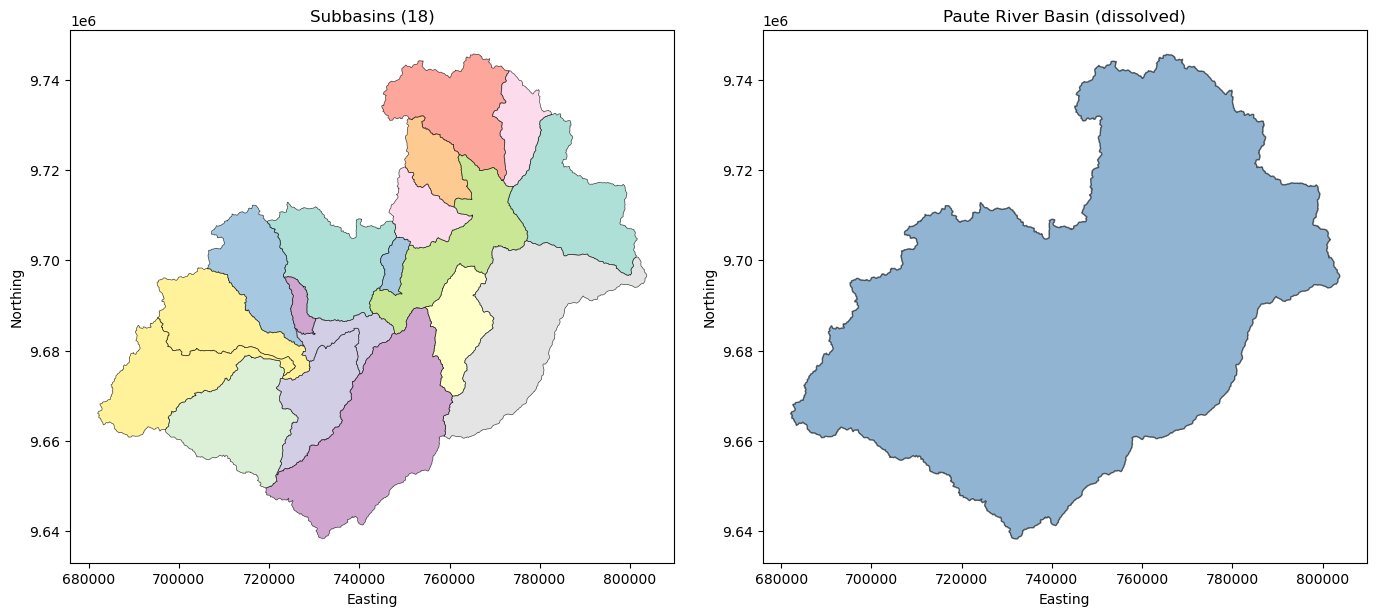

In [ ]:
# Dissolve subbasins into the full Paute river basin
subbasins = gpd.read_file(r"data\cuencas\SubcuencasPaute_fixed.gpkg")
print(f"Subbasins: {len(subbasins)} features, CRS: {subbasins.crs}")
print(f"Bounding box: {subbasins.total_bounds}")

# Buffer out slightly to close tiny gaps, union, then buffer back
EPS = 1  # 1 metre — enough to close gaps without distorting shape
merged_geom = subbasins.buffer(EPS).union_all().buffer(-EPS)
print(f"Geometry type after merge: {merged_geom.geom_type}")

# If still MultiPolygon, keep only the largest piece
if merged_geom.geom_type == "MultiPolygon":
    merged_geom = max(merged_geom.geoms, key=lambda g: g.area)
    print(f"Extracted largest polygon (area: {merged_geom.area:.0f} m²)")

paute_basin = gpd.GeoDataFrame({"name": ["Paute River Basin"]}, geometry=[merged_geom], crs=subbasins.crs)

out_path = r"data\cuencas\PauteBasin.gpkg"
paute_basin.to_file(out_path, driver="GPKG")
print(f"Saved dissolved basin to {out_path}")

# Quick plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

subbasins.plot(ax=axes[0], edgecolor="black", linewidth=0.5, cmap="Set3", alpha=0.7)
axes[0].set_title(f"Subbasins ({len(subbasins)})")

paute_basin.plot(ax=axes[1], edgecolor="black", linewidth=1, color="steelblue", alpha=0.6)
axes[1].set_title("Paute River Basin (dissolved)")

for a in axes:
    a.set_xlabel("Easting")
    a.set_ylabel("Northing")

plt.tight_layout()
plt.show()

Clipped DEM saved to data\dems\dem_paute_30m.tif
Shape: (1, 3498, 3938), CRS: EPSG:4326


c:\Users\UDA\anaconda3\envs\thesis\Lib\site-packages\matplotlib_scalebar\scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


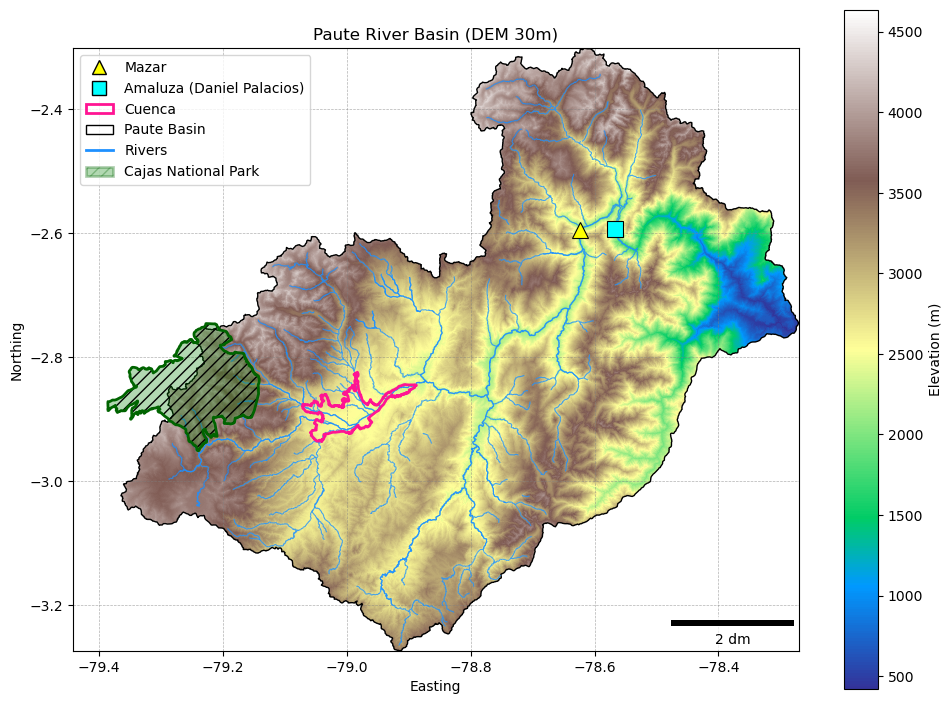

In [ ]:

dem_30m_path = r"C:\Soilgrids\data\dems\30m_largearea.tif"
clipped_dem_path = r"data\dems\dem_paute_30m.tif"

# Reproject basin boundary to match the DEM CRS
with rasterio.open(dem_30m_path) as src:
    dem_crs = src.crs

basin_reprojected = paute_basin.to_crs(dem_crs)

# Clip DEM to the Paute basin
with rasterio.open(dem_30m_path) as src:
    clipped, clipped_transform = rio_mask(
        src,
        basin_reprojected.geometry,
        crop=True,
        nodata=src.nodata if src.nodata is not None else -9999,
    )
    clipped_meta = src.meta.copy()

clipped_meta.update({
    "height": clipped.shape[1],
    "width": clipped.shape[2],
    "transform": clipped_transform,
    "nodata": clipped_meta.get("nodata", -9999),
})

# Save clipped DEM
with rasterio.open(clipped_dem_path, "w", **clipped_meta) as dst:
    dst.write(clipped)

print(f"Clipped DEM saved to {clipped_dem_path}")
print(f"Shape: {clipped.shape}, CRS: {clipped_meta['crs']}")

# Display
dem_clip = clipped[0].astype("float32")
nodata_val = clipped_meta["nodata"]
if nodata_val is not None:
    dem_clip[dem_clip == nodata_val] = np.nan
# Remove negative elevations (invalid values)
dem_clip[dem_clip < 0] = np.nan

dem_clip_bounds = rasterio.transform.array_bounds(
    clipped.shape[1], clipped.shape[2], clipped_transform
)

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor("white")
im = ax.imshow(
    dem_clip,
    extent=[dem_clip_bounds[0], dem_clip_bounds[2], dem_clip_bounds[1], dem_clip_bounds[3]],
    cmap="terrain",
    origin="upper",
    interpolation="nearest",
)
basin_reprojected.boundary.plot(ax=ax, color="black", linewidth=1, zorder=3, label="Paute Basin")
plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.7)

# Reservoirs (embalses) — plot each individually
presas = gpd.read_file(r"data\rivers_paute\presas\Presas_CRP.shp").to_crs(dem_crs)
reservoir_styles = {
    "Mazar":                      {"color": "yellow",  "marker": "^", "size": 120},
    "Amaluza (Daniel Palacios)":  {"color": "cyan",    "marker": "s", "size": 110},
}
for _, row in presas.iterrows():
    name = row["Nombre"]
    style = reservoir_styles.get(name)
    if style is None:
        continue
    ax.plot(row.geometry.x, row.geometry.y,
            marker=style["marker"], color=style["color"],
            markersize=12, markeredgecolor="black", markeredgewidth=0.8,
            zorder=6)
    
cajas = gpd.read_file(r"C:\Soilgrids\data\cajas\cajas\WDPA_WDOECM_Jan2026_Public_7913_shp-polygons.shp").to_crs(dem_crs)
cajas.plot(ax=ax, facecolor="green", edgecolor="none", alpha=0.3, hatch="///", zorder=5)
cajas.boundary.plot(ax=ax, color="darkgreen", linewidth=2, zorder=5)

# City of Cuenca
cuenca = gpd.read_file(r"data\adm_ecu\cuenca_ciudad.shp").to_crs(dem_crs)
cuenca.boundary.plot(ax=ax, color="deeppink", linewidth=2, zorder=5)

# Rivers
rivers = gpd.read_file(r"data\rivers_paute\Rios_CRP_25k_UTM_SAM56.shp").to_crs(dem_crs)
rivers.plot(ax=ax, color="dodgerblue", linewidth=0.8, alpha=0.8, zorder=4)

# Legend
legend_handles = [
    Line2D([0], [0], marker="^", color="w", markerfacecolor="yellow",
           markeredgecolor="black", markersize=10, label="Mazar"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="cyan",
           markeredgecolor="black", markersize=10, label="Amaluza (Daniel Palacios)"),
    Patch(edgecolor="deeppink", facecolor="none", linewidth=2, label="Cuenca"),
    Patch(edgecolor="black", facecolor="none", linewidth=1, label="Paute Basin"),
    Line2D([0], [0], color="dodgerblue", linewidth=2, label="Rivers"),
    Patch(edgecolor="darkgreen", facecolor="green", linewidth=2, alpha=0.3, hatch="///", label="Cajas National Park"),
    
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=10, framealpha=0.8)

# Grid lines
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6, color="gray", zorder=4)

# Scale bar (CRS units are metres)
scalebar = ScaleBar(1, units="m", location="lower right", length_fraction=0.2,
                    box_alpha=0.7, font_properties={"size": 10})
ax.add_artist(scalebar)

ax.set_title("Paute River Basin (DEM 30m)")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
plt.tight_layout()
plt.show()

In [ ]:

# Load provinces (adm1), drop Galápagos, dissolve to mainland boundary
provinces = gpd.read_file(r"C:\Soilgrids\data\adm_ecu\ecu_adm_adm1_2024.shp")
print("Provinces:", provinces["ADM1_ES"].tolist())

dissolved = provinces[provinces["ADM1_ES"] != "Galápagos"].dissolve()
print(f"Dissolved geometry type: {dissolved.geometry.iloc[0].geom_type}")

# Keep only the largest polygon — removes small coastal islands
geom = dissolved.geometry.iloc[0]
if geom.geom_type == "MultiPolygon":
    largest = max(geom.geoms, key=lambda g: g.area)
    print(f"Kept largest polygon from {len(list(geom.geoms))}-part MultiPolygon")
else:
    largest = geom

# Strip ALL interior rings (holes) — province boundary gaps leave tiny topology
# artefacts that appear as black specks on the continent when plotted
clean_geom = ShapelyPolygon(largest.exterior)

mainland_ecu = gpd.GeoDataFrame(
    {"name": ["Mainland Ecuador"]},
    geometry=[clean_geom],
    crs=dissolved.crs,
)
print(f"Interior rings removed: {len(list(largest.interiors))} holes stripped")
print(f"Final geometry type: {mainland_ecu.geometry.iloc[0].geom_type}")

out_path = r"C:\Soilgrids\data\adm_ecu\ecu_mainland_boundary.shp"
mainland_ecu.to_file(out_path)
print(f"Saved → {out_path}")


Provinces: ['Azuay', 'Bolívar', 'Cañar', 'Carchi', 'Cotopaxi', 'Chimborazo', 'El Oro', 'Esmeraldas', 'Guayas', 'Imbabura', 'Loja', 'Los Ríos', 'Manabí', 'Morona Santiago', 'Napo', 'Pastaza', 'Pichincha', 'Tungurahua', 'Zamora Chinchipe', 'Galápagos', 'Sucumbíos', 'Orellana', 'Santo Domingo de los Tsáchilas', 'Santa Elena']
Dissolved geometry type: MultiPolygon
Kept largest polygon from 4-part MultiPolygon
Interior rings removed: 74 holes stripped
Final geometry type: Polygon
Saved → C:\Soilgrids\data\adm_ecu\ecu_mainland_boundary.shp


C:\Users\UDA\AppData\Local\Temp\ipykernel_8636\1847291855.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{lon:.1f}°" for lon in lon_labels])
C:\Users\UDA\AppData\Local\Temp\ipykernel_8636\1847291855.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{lat:.1f}°" for lat in lat_labels])
C:\Users\UDA\AppData\Local\Temp\ipykernel_8636\1847291855.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


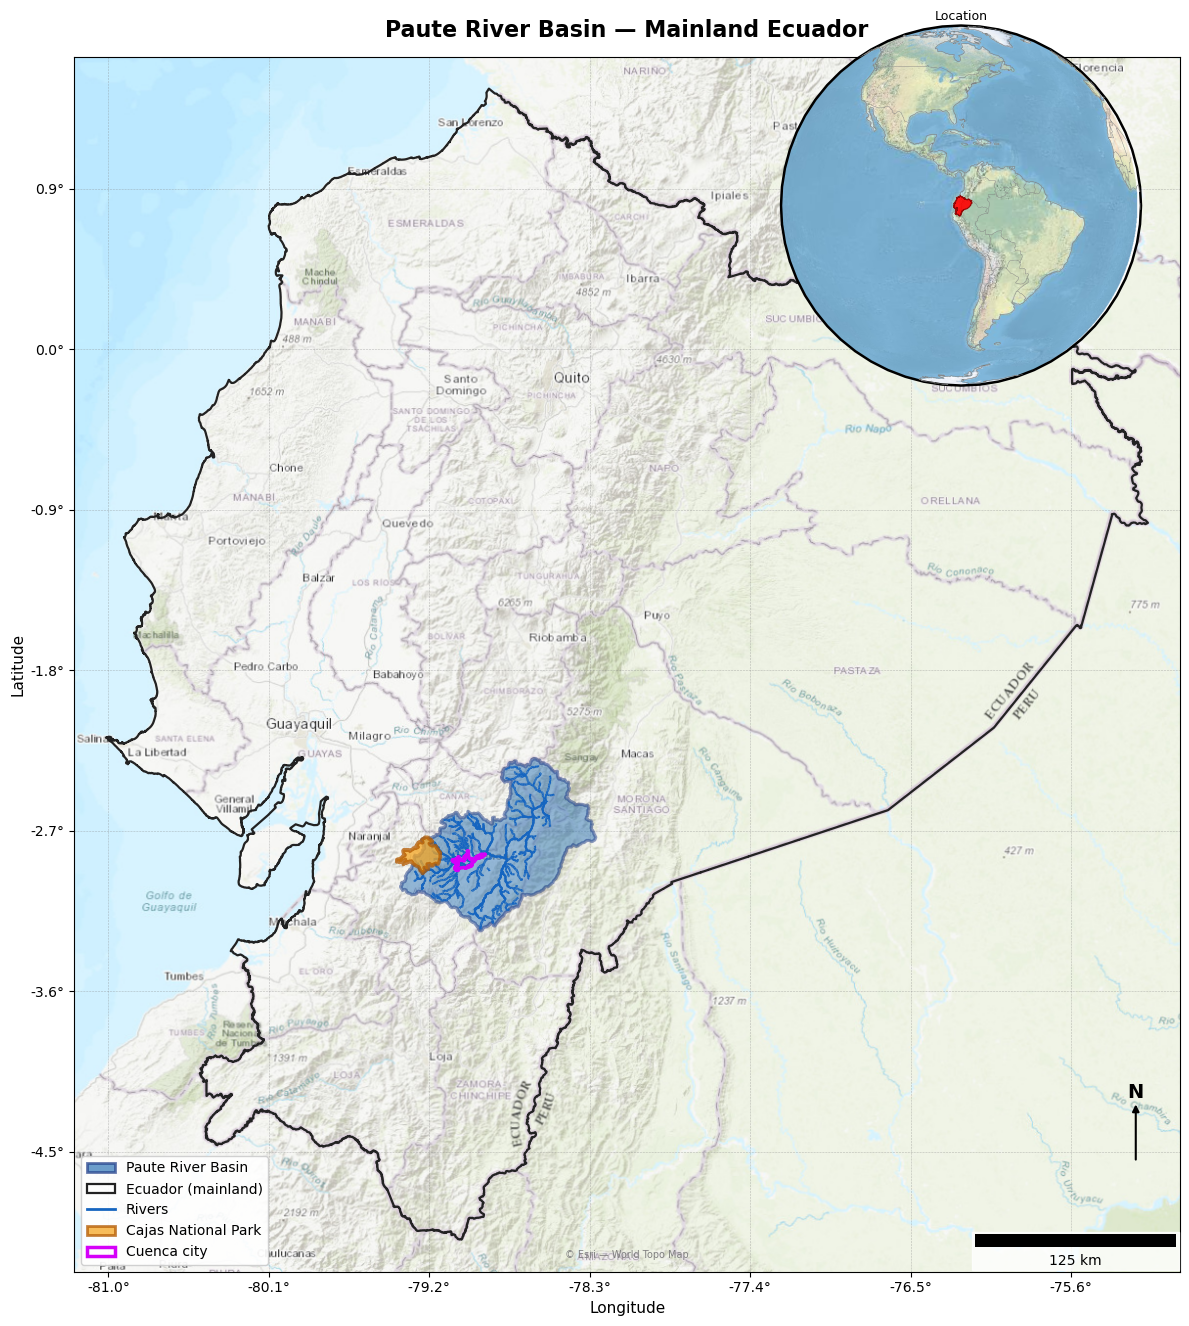

Saved → maps/paute_basin_thesis_intro.png


In [ ]:


# --- Load layers ---
mainland_proj = mainland_ecu.to_crs(PROJ_CRS)
mainland_wgs  = mainland_ecu.to_crs("EPSG:4326")   # WGS84 for globe inset — mainland only
paute         = gpd.read_file(r"data\cuencas\PauteBasin.gpkg").to_crs(PROJ_CRS)
rivers        = gpd.read_file(r"data\rivers_paute\Rios_CRP_25k_UTM_SAM56.shp").to_crs(PROJ_CRS)
cuenca        = gpd.read_file(r"data\adm_ecu\cuenca_ciudad.shp").to_crs(PROJ_CRS)
cajas         = gpd.read_file(r"C:\Soilgrids\data\cajas\cajas\WDPA_WDOECM_Jan2026_Public_7913_shp-polygons.shp").to_crs(PROJ_CRS)

minx, miny, maxx, maxy = mainland_proj.total_bounds
PAD = 20_000

fig = plt.figure(figsize=(12, 14))
ax = fig.add_subplot(111)

ax.set_xlim(minx - PAD, maxx + PAD)
ax.set_ylim(miny - PAD, maxy + PAD)
ax.set_autoscale_on(False)

# WorldTopoMap: terrain + city/town labels + roads — ideal for regional thesis maps
ctx.add_basemap(ax, crs=PROJ_CRS, source=ctx.providers.Esri.WorldTopoMap,
                zoom=8, attribution=False)
ax.text(0.5, 0.01, "© Esri — World Topo Map",
        transform=ax.transAxes, fontsize=7, color="gray", ha="center", va="bottom", zorder=10)

# --- Layers (ordered back → front) ---
mainland_proj.plot(ax=ax, facecolor="none", edgecolor="#222222", linewidth=1.6, zorder=3)
paute.plot(ax=ax, facecolor="#2E75B6", edgecolor="#1F3C88", linewidth=2.2, alpha=0.50, zorder=4)
rivers.plot(ax=ax, color="#1565C0", linewidth=1.4, alpha=1.0, zorder=5)
cajas.plot(ax=ax, facecolor="#F5A623", edgecolor="#B35900", linewidth=2.5, alpha=0.75, zorder=6)
cuenca.boundary.plot(ax=ax, color="#D500F9", linewidth=2.5, zorder=7)

# Lat/lon tick labels
proj_to_geo = Transformer.from_crs(PROJ_CRS, "EPSG:4326", always_xy=True)
xticks = ax.get_xticks()
yticks = ax.get_yticks()
lon_labels, _ = proj_to_geo.transform(xticks, np.full_like(xticks, (miny + maxy) / 2))
_, lat_labels = proj_to_geo.transform(np.full_like(yticks, (minx + maxx) / 2), yticks)
ax.set_xticklabels([f"{lon:.1f}°" for lon in lon_labels])
ax.set_yticklabels([f"{lat:.1f}°" for lat in lat_labels])

ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5, color="gray", zorder=1)
ax.set_title("Paute River Basin — Mainland Ecuador", fontsize=16, fontweight="bold", pad=14)
ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude", fontsize=11)

scalebar = ScaleBar(1, units="m", location="lower right", length_fraction=0.2,
                    box_alpha=0.8, font_properties={"size": 10})
ax.add_artist(scalebar)

legend_handles = [
    mpatches.Patch(facecolor="#2E75B6", edgecolor="#1F3C88", alpha=0.7, linewidth=2.0,
                   label="Paute River Basin"),
    mpatches.Patch(edgecolor="#222222", facecolor="none", linewidth=1.6,
                   label="Ecuador (mainland)"),
    Line2D([0], [0], color="#1565C0", linewidth=2.0, label="Rivers"),
    mpatches.Patch(facecolor="#F5A623", edgecolor="#B35900", alpha=0.75, linewidth=2.0,
                   label="Cajas National Park"),
    mpatches.Patch(edgecolor="#D500F9", facecolor="none", linewidth=2.5,
                   label="Cuenca city"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=10, framealpha=0.9)

ax.annotate("N", xy=(0.96, 0.14), xycoords="axes fraction", fontsize=14,
            fontweight="bold", ha="center", va="bottom")
ax.annotate("", xy=(0.96, 0.14), xytext=(0.96, 0.09),
            xycoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", lw=1.5, color="black"))

# --- Globe inset — highlight mainland Ecuador only (no Galápagos) ---
globe_crs = ccrs.Orthographic(central_longitude=-78.5, central_latitude=-1.8)
ax_glob = fig.add_axes([0.655, 0.70, 0.30, 0.26], projection=globe_crs)
ax_glob.set_global()

esri_tiles = cimgt.GoogleTiles(
    url="https://server.arcgisonline.com/ArcGIS/rest/services/"
        "World_Physical_Map/MapServer/tile/{z}/{y}/{x}"
)
ax_glob.add_image(esri_tiles, 2)
ax_glob.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="gray", zorder=3)
ax_glob.add_feature(cfeature.BORDERS,   linewidth=0.3, edgecolor="gray", zorder=3)

# mainland_wgs: single clean polygon — Galápagos excluded
ax_glob.add_geometries(
    mainland_wgs.geometry, crs=ccrs.PlateCarree(),
    facecolor="red", edgecolor="darkred", linewidth=0.8, alpha=0.9, zorder=4,
)

ax_glob.set_title("Location", fontsize=9, pad=4)
ax_glob.spines["geo"].set_linewidth(1.8)
ax_glob.spines["geo"].set_edgecolor("black")

plt.tight_layout()
plt.savefig(r"maps\paute_basin_thesis_intro.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved → maps/paute_basin_thesis_intro.png")
